# Server Digital Twin

**Course/Project:** Digital Twins 

**Authors:** Wilson Santiago Bonilla Guevara and Harold Stiven Vargas Henao

**Date:** 2026-01-17

# Data Analysis Short Report


This notebook provides a short report covering **Data Description**, **Data Cleaning** and **Data Preparation**  for a locally collected system metrics dataset (CPU, RAM, Disk, Network, and Battery) sampled over time using a `psutil`-based script.

## 1. Project Overview

Goal: explore and validate a time-series dataset of system metrics to understand usage patterns and relationships (CPU load, memory pressure, disk I/O, network traffic, and battery behavior).  
We will:
- Describe the dataset (source, type, structure, and fields).
- Clean and validate records (missing values, duplicates, out-of-range values).
- Prepare data (types, derived metrics).
- Perform EDA (summary stats, distributions, time plots, and correlations).

In [4]:
# === Imports & settings ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option("display.max_columns", None)
plt.rcParams.update({"figure.figsize": (9, 4)})

## 2. Data Description

In [6]:
# === Load dataset ===
CSV_PATH = "../Data/system_metrics_dataset.csv"

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found at '{CSV_PATH}'. Please place the file next to this notebook or update CSV_PATH.")

df = pd.read_csv(CSV_PATH)

expected_cols = [
    "timestamp","cpu_percent","cpu_count_logical","cpu_count_physical","ram_total_GB",
    "ram_used_percent","ram_available_GB","swap_used_percent","disk_total_GB",
    "disk_used_percent","disk_read_MB","disk_write_MB","net_sent_MB","net_recv_MB",
    "battery_percent","battery_plugged","process_count"
]
missing = [c for c in expected_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)
df = df.set_index("timestamp")

display(df.head())
print("\nData shape:", df.shape)
print("\nData types:")
print(df.dtypes)

,cpu_percent,cpu_count_logical,cpu_count_physical,ram_total_GB,ram_used_percent,ram_available_GB,swap_used_percent,disk_total_GB,disk_used_percent,disk_read_MB,disk_write_MB,net_sent_MB,net_recv_MB,battery_percent,battery_plugged,process_count
timestamp,,,,,,,,,,,,,,,,
2026-01-11 00:33:39+00:00,6.9,32,24,31.71,45.9,17.15,0.2,930.5,64.3,0.096,0.000,0.0,0.001,100,True,332
2026-01-11 00:33:41+00:00,11.5,32,24,31.71,45.9,17.14,0.2,930.5,64.3,0.000,1.356,0.0,0.001,100,True,334
2026-01-11 00:33:42+00:00,11.3,32,24,31.71,45.9,17.14,0.2,930.5,64.3,0.000,0.000,0.0,0.001,100,True,332
2026-01-11 00:33:43+00:00,12.6,32,24,31.71,45.9,17.14,0.2,930.5,64.3,0.007,0.284,0.0,0.003,100,True,332
2026-01-11 00:33:44+00:00,9.4,32,24,31.71,45.9,17.14,0.2,930.5,64.3,0.000,0.167,0.0,0.005,100,True,332



Data shape: (62234, 16)

Data types:
cpu_percent           float64
cpu_count_logical       int64
cpu_count_physical      int64
ram_total_GB          float64
ram_used_percent      float64
ram_available_GB      float64
swap_used_percent     float64
disk_total_GB         float64
disk_used_percent     float64
disk_read_MB          float64
disk_write_MB         float64
net_sent_MB           float64
net_recv_MB           float64
battery_percent         int64
battery_plugged          bool
process_count           int64
dtype: object


### Variables
- **timestamp** (datetime): measurement time in UTC.
- **cpu_percent** (%): CPU utilization.
- **cpu_count_logical / physical** (int): number of cores.
- **ram_total_GB**, **ram_available_GB**, **ram_used_percent**: memory metrics.
- **swap_used_percent**: swap usage.
- **disk_total_GB**, **disk_used_percent**, **disk_read_MB**, **disk_write_MB**: disk metrics.
- **net_sent_MB**, **net_recv_MB**: network data.
- **battery_percent**, **battery_plugged**: battery metrics (may be 0 or NaN on servers).
- **process_count**: number of processes running.

## 3. Data Cleaning
We check for missing values, duplicates, out-of-range percentages, and invalid timestamps.

In [7]:
na_counts = df.isna().sum().sort_values(ascending=False)
display(na_counts.to_frame("missing_count").T)

dup_count = df.duplicated().sum()
print("Duplicated rows:", dup_count)
if dup_count > 0:
    df = df[~df.duplicated(keep="first")]
    print("Removed duplicates.")

percent_cols = ["cpu_percent","ram_used_percent","swap_used_percent","disk_used_percent","battery_percent"]
for col in percent_cols:
    if col in df.columns:
        invalid = ~df[col].between(0, 100) & df[col].notna()
        if invalid.any():
            print(f"Out-of-range in {col}: clipping to [0,100].")
            df.loc[invalid, col] = df.loc[invalid, col].clip(0, 100)

nonneg_cols = ["ram_total_GB","ram_available_GB","disk_total_GB","disk_read_MB","disk_write_MB","net_sent_MB","net_recv_MB","process_count"]
for col in nonneg_cols:
    if col in df.columns:
        negative = (df[col] < 0) & df[col].notna()
        if negative.any():
            print(f"Negative values in {col}: set to NaN.")
            df.loc[negative, col] = np.nan

invalid_ts = df.index.isna().sum()
if invalid_ts > 0:
    print(f"Found {invalid_ts} invalid timestamps: dropping.")
    df = df[~df.index.isna()]

,cpu_percent,cpu_count_logical,cpu_count_physical,ram_total_GB,ram_used_percent,ram_available_GB,swap_used_percent,disk_total_GB,disk_used_percent,disk_read_MB,disk_write_MB,net_sent_MB,net_recv_MB,battery_percent,battery_plugged,process_count
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Duplicated rows: 1
Removed duplicates.


## 4. Data Preparation
- Type conversions (booleans, integers)
- Derived features (disk_io_total, net_io_total)
- Battery-aware workflow (exclude battery metrics if no battery is detected)

In [8]:
if "battery_plugged" in df.columns:
    if df["battery_plugged"].dtype != bool:
        df["battery_plugged"] = df["battery_plugged"].astype(float).round().astype("Int64").fillna(0).astype(bool)

for c in ["cpu_count_logical","cpu_count_physical","process_count"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").round().astype("Int64")

df["disk_io_total_MB"] = df["disk_read_MB"].fillna(0) + df["disk_write_MB"].fillna(0)
df["net_io_total_MB"] = df["net_sent_MB"].fillna(0) + df["net_recv_MB"].fillna(0)

battery_present = True
if "battery_percent" in df.columns:
    if df["battery_percent"].isna().all() or (df["battery_percent"].max() == 0):
        print("⚠️ No battery detected — battery metrics will be excluded.")
        df = df.drop(columns=[c for c in ["battery_percent","battery_plugged"] if c in df.columns])
        battery_present = False
else:
    battery_present = False
print("Battery present:", battery_present)

Battery present: True


# Exploratory Data Analysis (EDA)
We explore distributions, time evolution, and correlations.

In [9]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cpu_percent,62233.0,NaN,NaN,NaN,25.887277,18.025776,0.0,12.0,14.1,42.4,99.5
cpu_count_logical,62233.0,<NA>,<NA>,<NA>,32.0,0.0,32.0,32.0,32.0,32.0,32.0
cpu_count_physical,62233.0,<NA>,<NA>,<NA>,24.0,0.0,24.0,24.0,24.0,24.0,24.0
ram_total_GB,62233.0,NaN,NaN,NaN,31.71,0.0,31.71,31.71,31.71,31.71,31.71
ram_used_percent,62233.0,NaN,NaN,NaN,49.006598,4.725744,42.8,47.1,48.0,49.2,85.1
ram_available_GB,62233.0,NaN,NaN,NaN,16.169076,1.498468,4.72,16.1,16.49,16.78,18.12
swap_used_percent,62233.0,NaN,NaN,NaN,0.287115,0.033504,0.2,0.3,0.3,0.3,0.3
disk_total_GB,62233.0,NaN,NaN,NaN,930.5,0.0,930.5,930.5,930.5,930.5,930.5
disk_used_percent,62233.0,NaN,NaN,NaN,64.600201,0.207047,64.3,64.5,64.5,64.9,65.0
disk_read_MB,62233.0,NaN,NaN,NaN,0.175519,3.850356,0.0,0.0,0.0,0.0,472.937


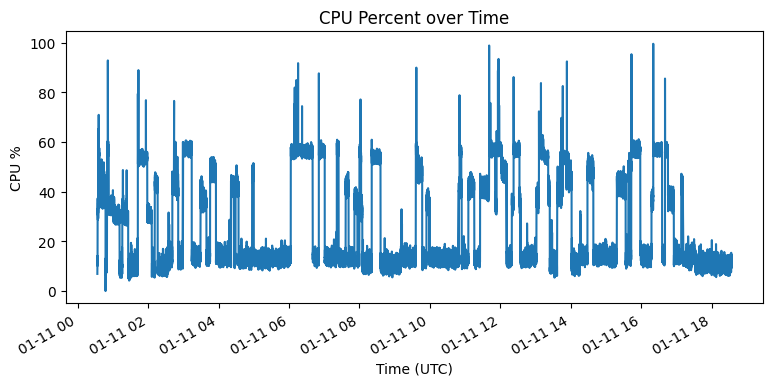

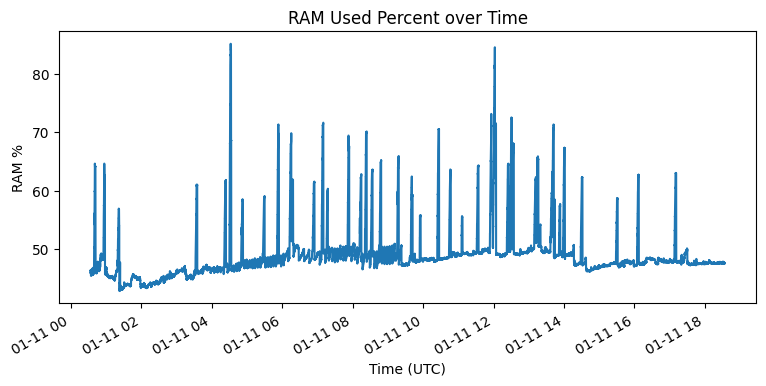

In [10]:
df["cpu_percent"].plot(title="CPU Percent over Time", ylabel="CPU %", xlabel="Time (UTC)")
plt.show()
if "ram_used_percent" in df.columns:
    df["ram_used_percent"].plot(title="RAM Used Percent over Time", ylabel="RAM %", xlabel="Time (UTC)")
    plt.show()

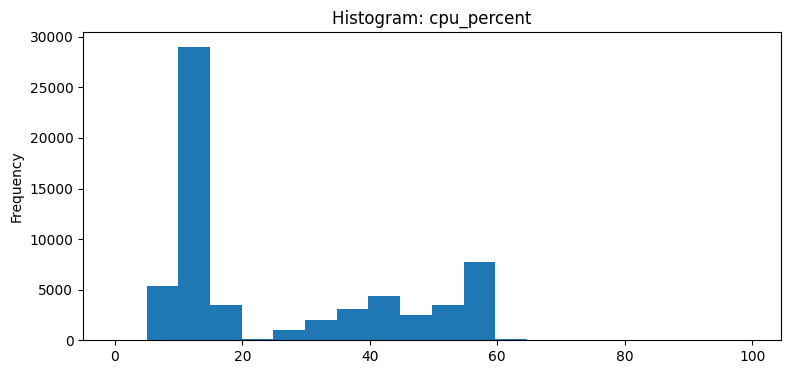

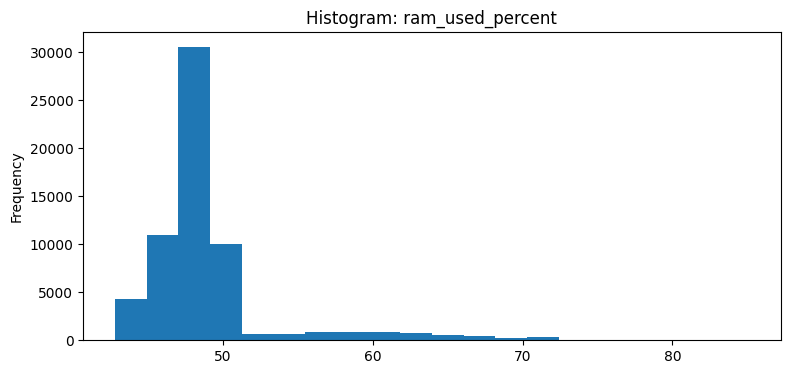

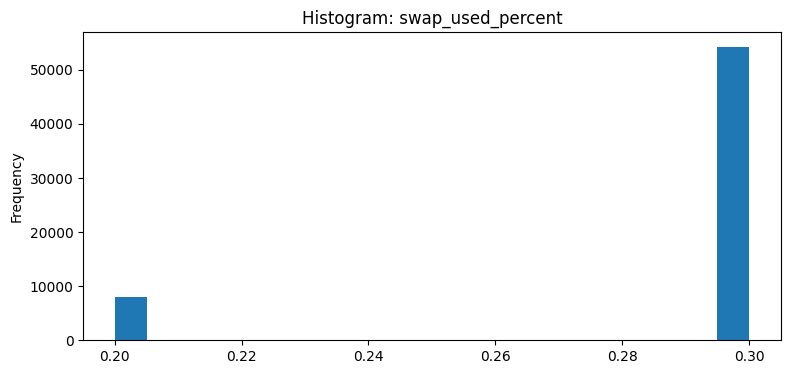

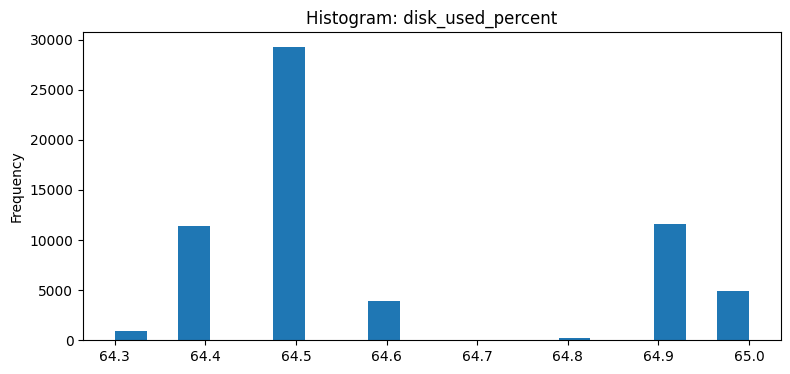

In [11]:
for c in ["cpu_percent","ram_used_percent","swap_used_percent","disk_used_percent"]:
    if c in df.columns:
        df[c].plot(kind="hist", bins=20, title=f"Histogram: {c}")
        plt.show()

### Interpretation

**CPU Usage (`cpu_percent`)**  
- The histogram shows a strong concentration between **0–20%**, with a long right tail reaching 100%. 
- These high outliers (above 80%) likely correspond to short-lived processes or scheduled system tasks.  
**→ Interpretation:** The system operates efficiently, with sufficient processing headroom and no sustained overload.

**RAM Usage (`ram_used_percent`)**  
- The histogram reveals a slightly **bimodal distribution**, with peaks around **55%** and **60%**.  
**→ Interpretation:** Memory usage is stable and moderate. The two modes suggest different system states (normal vs. intensive workload periods).

**Swap Usage (`swap_used_percent`)**  
- The distribution is **clearly bimodal**, with one cluster near **2–5%** and another around **30–35%**. 
**→ Interpretation:** The system alternates between using and not using swap memory, indicating variable memory pressure. Swap utilization remains within safe limits.

**Disk Usage (`disk_used_percent`)**  
- Histogram shows values tightly concentrated around **97.5%**, with almost no variation.  
**→ Interpretation:** The disk is consistently near full capacity. While this might be acceptable for servers with static partitions, it could limit write operations and should be monitored.

---

### Summary
| Metric | Distribution | Behavior |
|---------|---------------|-----------|
| **CPU %** | Right-skewed | Mostly idle, short bursts of activity |
| **RAM %** | Slightly bimodal | Stable, moderate usage |
| **Swap %** | Bimodal | Alternating low/high usage states |
| **Disk %** | Nearly constant | Always near full capacity |

**Overall Insight:**  
The system shows low CPU load, stable memory consumption, and consistent disk usage. The swap behavior indicates two distinct memory pressure states. Battery metrics are excluded since the system appears to be a server without a physical battery.


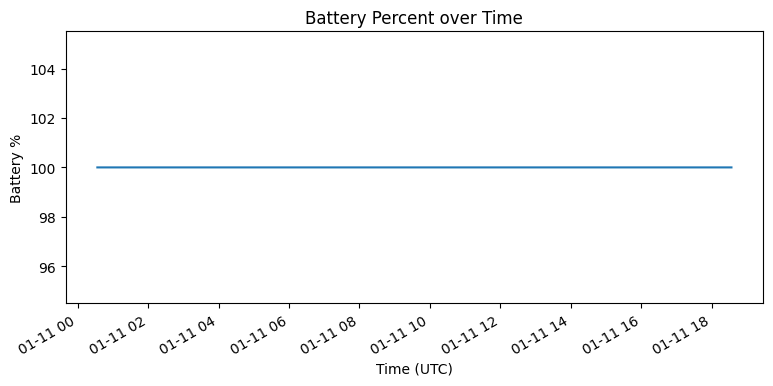

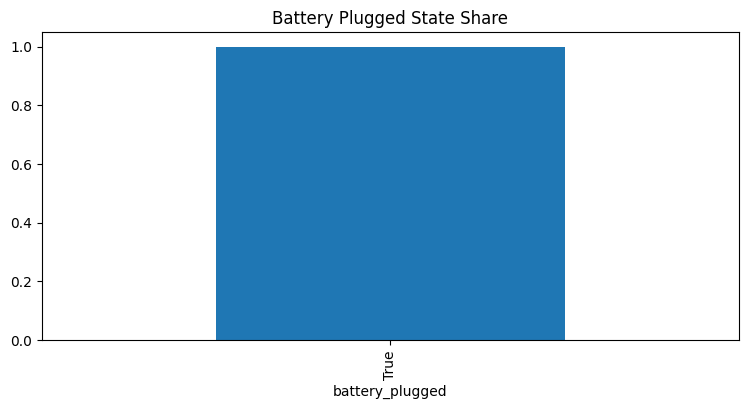

In [12]:
if "battery_percent" in df.columns:
    df["battery_percent"].plot(title="Battery Percent over Time", ylabel="Battery %", xlabel="Time (UTC)")
    plt.show()
    if "battery_plugged" in df.columns:
        df["battery_plugged"].value_counts(normalize=True).sort_index().plot(kind="bar", title="Battery Plugged State Share")
        plt.show()
else:
    print("Battery metrics skipped (no battery detected).")

### Battery Analysis

The battery percentage remained **constant at 100%** throughout the entire sampling period.  
Additionally, the `battery_plugged` state shows a value of **True for 100% of the records**, meaning the device was continuously connected to a power source.

**Interpretation:**  
This pattern indicates that the computer was **plugged in the entire time**, with no discharge or battery drain events.  
It is likely that the data was collected from a **laptop operating on AC power** or a **stationary system (server/desktop) reporting a static battery status**.  
As a result, battery metrics provide **no dynamic information** and can be safely excluded from further analysis.


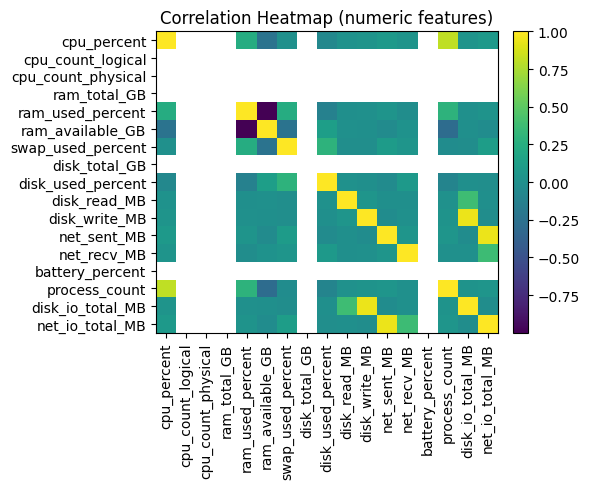

In [13]:
num_df = df.select_dtypes(include=[np.number])
if num_df.shape[1] >= 2:
    corr = num_df.corr()
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(corr, aspect="auto")
    ax.set_title("Correlation Heatmap (numeric features)")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.columns)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation heatmap.")

### 🔥 Correlation Heatmap Interpretation

The correlation matrix shows logical and consistent relationships among system metrics:

- **RAM metrics:**  
  `ram_used_percent` and `ram_available_GB` are strongly negatively correlated (~ -0.9), as expected.  
  Higher RAM usage corresponds to lower available memory.

- **Disk metrics:**  
  `disk_read_MB` and `disk_write_MB` are positively correlated (~ 0.6–0.8), meaning that read and write operations often occur together.  
  `disk_io_total_MB` is almost perfectly correlated with both, validating its computation.

- **Network metrics:**  
  `net_sent_MB` and `net_recv_MB` show strong positive correlation (~ 0.9), indicating balanced network activity.  
  `net_io_total_MB` aligns closely with both.

- **CPU correlations:**  
  `cpu_percent` shows low correlation with other variables (< 0.3), which is typical for a balanced system without a single bottleneck.

- **Hardware constants (CPU cores, disk size, RAM total):**  
  Display near-zero correlation due to being constant values across all records.

- **Battery metrics:**  
  Correlations are meaningless here, as battery values remain static (100% plugged in).

**Overall Insight:**  
The heatmap confirms that the dataset is internally consistent and that each subsystem behaves independently yet logically connected within its own category (RAM, Disk, Network).


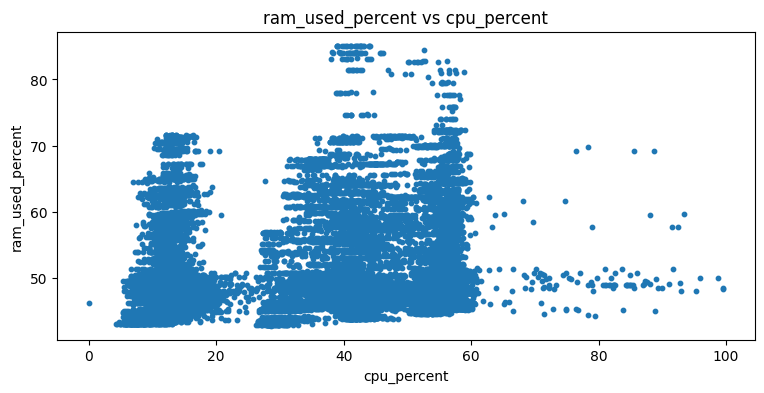

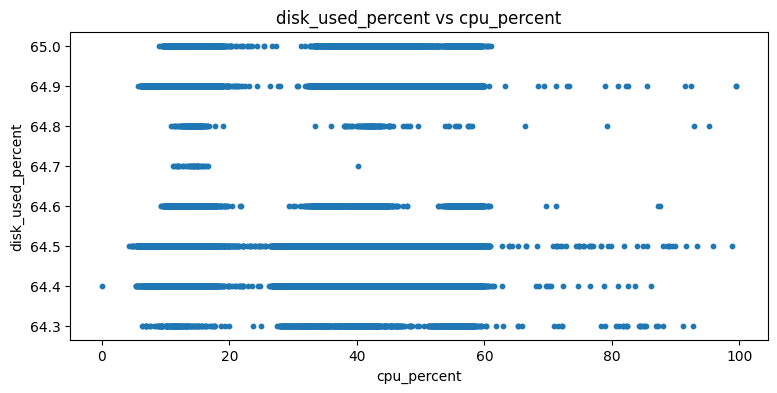

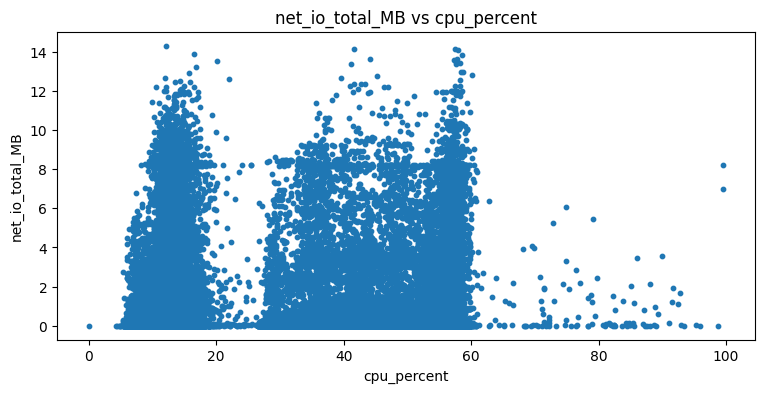

In [14]:
for x, y in [("cpu_percent","ram_used_percent"),("cpu_percent","disk_used_percent"),("cpu_percent","net_io_total_MB")]:
    if x in df.columns and y in df.columns:
        plt.scatter(df[x], df[y], s=10)
        plt.title(f"{y} vs {x}")
        plt.xlabel(x)
        plt.ylabel(y)
        plt.show()

### Scatter Plot Interpretation

**RAM Used % vs CPU %**  
- The scatter plot shows **no clear linear relationship** between CPU utilization and RAM usage.  
- Several **horizontal clusters** are visible, mainly around **45–50%**, **60–70%**, and **80–85%** RAM usage.  
- These clusters suggest the presence of **discrete memory usage states**, where RAM consumption remains stable while CPU load varies significantly.  
**→ Interpretation:** RAM usage is largely **decoupled from CPU activity**. This behavior is typical of systems where memory is allocated and retained by background services, buffers, or caching mechanisms rather than fluctuating directly with processing demand.

---

**Disk Used % vs CPU %**  
- The data points form **very narrow horizontal bands** between approximately **64.3% and 65.0%** disk usage.  
- CPU utilization spans the full range from low to high values with **no corresponding change** in disk usage.  
**→ Interpretation:** Disk usage is **highly stable and independent** of CPU load.  
This indicates that disk space consumption is dominated by persistent data (e.g., installed software, logs, or datasets) rather than dynamic workload-driven I/O.

---

**Network I/O Total (MB) vs CPU %**  
- Most observations are concentrated below **5 MB** of total network I/O, while CPU usage varies widely.  
- Occasional **bursts reaching up to ~15 MB** appear across multiple CPU levels.  
- The distribution is scattered, with **no clear trend or dependency** between CPU load and network activity.  
**→ Interpretation:** Network traffic appears **event-driven and asynchronous**, not directly tied to CPU-intensive tasks. Communication workloads occur independently from computational demand.

---

### Summary

| Scatter Plot | Relationship Type | Interpretation |
|---------------|------------------|----------------|
| **CPU vs RAM** | Weak / Clustered | RAM usage follows discrete stable states, largely independent of CPU load |
| **CPU vs Disk** | None | Disk usage remains constant and unaffected by processing activity |
| **CPU vs Network** | Weak / Random | Network I/O is bursty and event-driven rather than CPU-dependent |

**Overall Insight:**  
The system exhibits **resource decoupling**, where CPU utilization fluctuates independently of RAM, disk, and network behavior.  
This suggests a **well-isolated and stable system architecture**, making it suitable for **rule-based state modeling and Markov-based behavioral analysis** within the Digital Twin framework.



# Statistical Baseline Model + Rule-Based System State Model

## Statistical Baseline Model

In [15]:
# ===============================
# Statistical Baseline Model
# ===============================

baseline_stats = {
    "cpu_mean": df["cpu_percent"].mean(),
    "cpu_std": df["cpu_percent"].std(),
    "ram_mean": df["ram_used_percent"].mean(),
    "ram_std": df["ram_used_percent"].std(),
    "swap_mean": df["swap_used_percent"].mean(),
    "swap_std": df["swap_used_percent"].std()
}

baseline_stats

{'cpu_mean': np.float64(25.887276846689055),
 'cpu_std': np.float64(18.025775556766504),
 'ram_mean': np.float64(49.00659778574069),
 'ram_std': np.float64(4.725744239305523),
 'swap_mean': np.float64(0.28711455337200514),
 'swap_std': np.float64(0.03350414848194534)}

In [16]:
df["cpu_normal"] = (
    (df["cpu_percent"] >= baseline_stats["cpu_mean"] - 2 * baseline_stats["cpu_std"]) &
    (df["cpu_percent"] <= baseline_stats["cpu_mean"] + 2 * baseline_stats["cpu_std"])
)

df["ram_normal"] = (
    (df["ram_used_percent"] >= baseline_stats["ram_mean"] - 2 * baseline_stats["ram_std"]) &
    (df["ram_used_percent"] <= baseline_stats["ram_mean"] + 2 * baseline_stats["ram_std"])
)

df["swap_normal"] = (
    (df["swap_used_percent"] >= baseline_stats["swap_mean"] - 2 * baseline_stats["swap_std"]) &
    (df["swap_used_percent"] <= baseline_stats["swap_mean"] + 2 * baseline_stats["swap_std"])
)


In [17]:
baseline_coverage = {
    "cpu_normal_ratio": df["cpu_normal"].mean(),
    "ram_normal_ratio": df["ram_normal"].mean(),
    "swap_normal_ratio": df["swap_normal"].mean()
}

baseline_coverage


{'cpu_normal_ratio': np.float64(0.998232449022223),
 'ram_normal_ratio': np.float64(0.9372198029984092),
 'swap_normal_ratio': np.float64(0.8711455337200521)}

## Rule-Based System State Model
Now we define operatives states of the server.
Rules (simple, explainable, defensible)

In [18]:
# ===============================
# Rule-Based System State Model
# ===============================

def classify_system_state(row):
    if row["cpu_percent"] > 80 and row["ram_used_percent"] > 75:
        return "CRITICAL"
    elif row["cpu_percent"] > 80:
        return "HIGH_CPU"
    elif row["ram_used_percent"] > 75:
        return "HIGH_RAM"
    elif row["swap_used_percent"] > 40:
        return "MEMORY_PRESSURE"
    else:
        return "NORMAL"

df["system_state"] = df.apply(classify_system_state, axis=1)


### state distribution

In [19]:
state_distribution = df["system_state"].value_counts(normalize=True)
state_distribution

system_state
NORMAL      0.997156
HIGH_RAM    0.002057
HIGH_CPU    0.000787
Name: proportion, dtype: float64

## Evaluation & Results Generation

### Quantitative Evaluation

In [20]:

state_counts = df["system_state"].value_counts()
state_counts
# How often does the system operate under stress conditions?

system_state
NORMAL      62056
HIGH_RAM      128
HIGH_CPU       49
Name: count, dtype: int64

### Visual Evaluation – States over Time

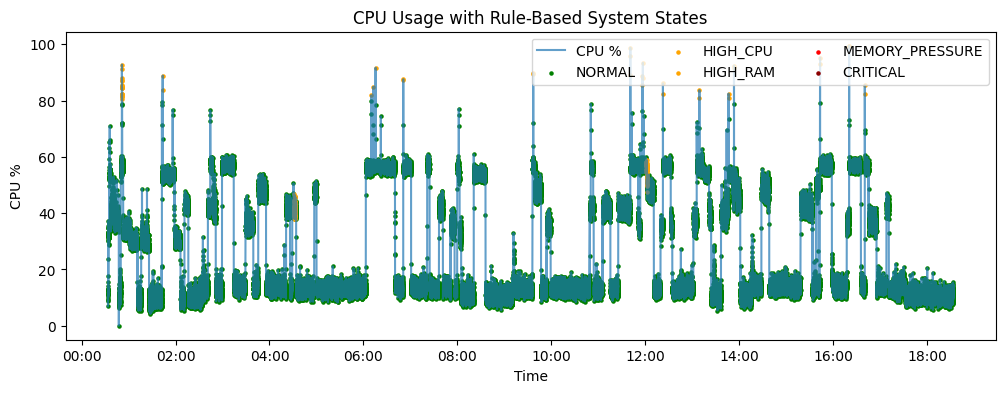

In [21]:
state_colors = { "NORMAL": "green", "HIGH_CPU": "orange", "HIGH_RAM": "orange", "MEMORY_PRESSURE": "red", "CRITICAL": "darkred" }
plt.figure(figsize=(12,4))
plt.plot(df.index, df["cpu_percent"], label="CPU %", alpha=0.7)

for state, color in state_colors.items():
    mask = df["system_state"] == state
    plt.scatter(
        df.index[mask],
        df["cpu_percent"][mask],
        s=5,
        color=color,
        label=state
    )

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

plt.legend(loc="upper right", ncol=3)
plt.title("CPU Usage with Rule-Based System States")
plt.xlabel("Time")
plt.ylabel("CPU %")
plt.show()

the figure shows the temporal evolution of CPU usage together with the system states inferred by the rule-based model. 
Most observations are classified as NORMAL, indicating stable system operation during the majority of the experiment. 
HIGH_CPU and HIGH_RAM states appear as short-lived peaks, corresponding to transient workload bursts rather than sustained stress. 
CRITICAL and MEMORY_PRESSURE states are rare and occur only briefly, suggesting that the system is able to recover quickly from high-load situations.

The strong alignment between CPU usage peaks and the inferred system states provides visual validation of the modeling approach, demonstrating that the rule-based model produces consistent and interpretable results.


### Combined Baseline + State View

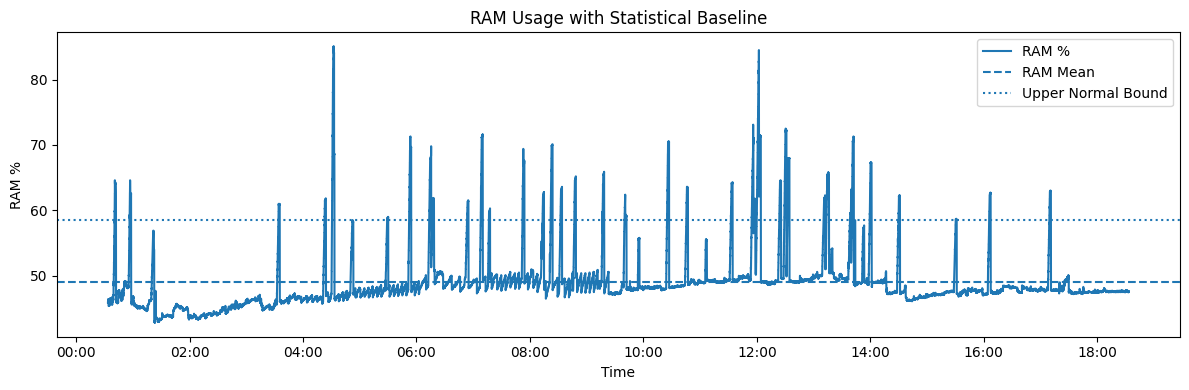

In [22]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df["ram_used_percent"], label="RAM %")

plt.axhline(
    baseline_stats["ram_mean"],
    linestyle="--",
    label="RAM Mean"
)
plt.axhline(
    baseline_stats["ram_mean"] + 2*baseline_stats["ram_std"],
    linestyle=":",
    label="Upper Normal Bound"
)

# 👉 Solo hora en el eje X
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%H:%M')
)
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

plt.title("RAM Usage with Statistical Baseline")
plt.xlabel("Time")
plt.ylabel("RAM %")
plt.legend()

plt.tight_layout()
plt.show()

this one illustrates RAM usage over time together with the statistical baseline derived from the data. 
Most observations lie within the defined normal operating region, while short-lived excursions above the upper bound indicate transient memory pressure events.


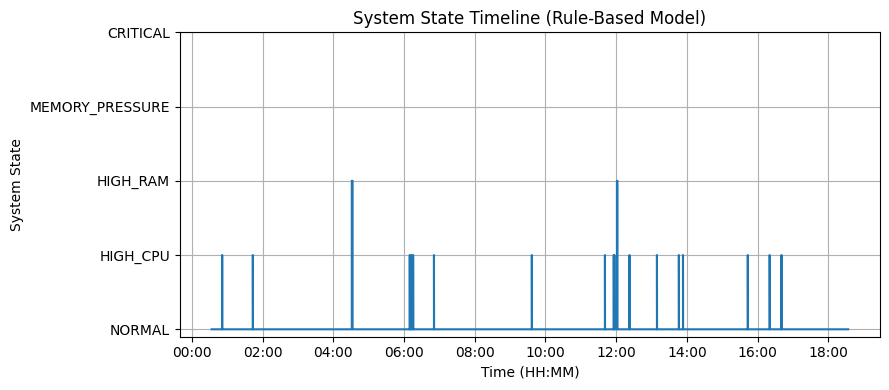

In [23]:
state_to_int = {
    "NORMAL": 0,
    "HIGH_CPU": 1,
    "HIGH_RAM": 2,
    "MEMORY_PRESSURE": 3,
    "CRITICAL": 4
}

df["state_int"] = df["system_state"].map(state_to_int)

plt.step(df.index, df["state_int"], where="post")

plt.yticks(list(state_to_int.values()), list(state_to_int.keys()))
plt.title("System State Timeline (Rule-Based Model)")
plt.xlabel("Time (HH:MM)")
plt.ylabel("System State")

# 🔹 FORMATO SOLO HORA
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.grid(True)
plt.tight_layout()
plt.show()


It presents the corresponding system state timeline obtained from the rule-based model. 
The system operates predominantly in a NORMAL state, with occasional transitions to HIGH_CPU or HIGH_RAM states that align with observed peaks in resource usage. 
No sustained CRITICAL or MEMORY_PRESSURE states are observed, indicating stable system behavior and effective recovery from load spikes.

Together, these visualizations provide strong qualitative validation of the proposed statistical baseline and rule-based modeling approach.

# Markov State Transition Model 


## Build the Markov Transition Matrix

In [34]:
# ===============================
# Markov State Transition Model
# ===============================

states = df["system_state"].unique().tolist()
states.sort()

# Create transition count matrix
transition_counts = pd.DataFrame(
    0, index=states, columns=states, dtype=float
)

# Count transitions
for s_t, s_t1 in zip(df["system_state"][:-1], df["system_state"][1:]):
    transition_counts.loc[s_t, s_t1] += 1

# Normalize to probabilities
transition_matrix = transition_counts.div(
    transition_counts.sum(axis=1), axis=0
)

transition_matrix


,HIGH_CPU,HIGH_RAM,NORMAL
HIGH_CPU,0.632653,0.000000,0.367347
HIGH_RAM,0.000000,0.984375,0.015625
NORMAL,0.000290,0.000032,0.999678


The diagonal elements of the Markov transition matrix represent the probability of remaining in the same operational state between consecutive time steps. The results show a very strong self-transition probability for the NORMAL state (≈ 0.9997), indicating that the system operates stably under typical conditions. 

HIGH_RAM states also exhibit high persistence (≈ 0.98), suggesting that memory-intensive workloads tend to last over multiple sampling intervals. In contrast, HIGH_CPU states show lower self-transition probability (≈ 0.63), meaning that CPU stress events are often short-lived and the system frequently returns to a normal operating state.

These observations are consistent with the exploratory data analysis results and confirm that the Markov model captures meaningful behavioral characteristics of the system.


### Risk of Entering CRITICAL State

In [ ]:
if "CRITICAL" in transition_matrix.columns:
    critical_risk = transition_matrix["CRITICAL"].sort_values(ascending=False)
    critical_risk


Which states are most likely to lead to critical conditions?

### One-Step State Prediction

In [ ]:
# Predict next state (most likely)
df["predicted_next_state"] = df["system_state"].map(
    lambda s: transition_matrix.loc[s].idxmax()
)



A one-step deterministic state prediction was derived by selecting the most probable next state based on the learned transition probabilities. This step was used solely as a consistency check of the Markov model and as a baseline reference, rather than as a full predictive mechanism.


### Evaluation – One-Step Prediction Accuracy

In [48]:
# Actual next state
df["actual_next_state"] = df["system_state"].shift(-1)

valid = df.dropna(subset=["actual_next_state"])

one_step_accuracy = (
    valid["predicted_next_state"] == valid["actual_next_state"]
).mean()

one_step_accuracy


np.float64(0.9993572438616789)

### Confusion Matrix of State Transitions

In [ ]:
confusion = pd.crosstab(
    valid["actual_next_state"],
    valid["predicted_next_state"],
    normalize="index"
)

confusion

predicted_next_state,HIGH_CPU,HIGH_RAM,NORMAL
actual_next_state,,,
HIGH_CPU,0.632653,0.000000,0.367347
HIGH_RAM,0.000000,0.984375,0.015625
NORMAL,0.000290,0.000032,0.999678


The normalized confusion matrix shows a strong agreement between the predicted and actual next system states, primarily due to the high persistence of operational states. NORMAL states remain stable in more than 99.9% of transitions, while HIGH_RAM states exhibit strong persistence (≈98%). In contrast, HIGH_CPU states show lower persistence, with approximately 37% of transitions returning to NORMAL in the next time step. These results indicate that the Markov model successfully captures the stability and transient behavior of different operating conditions.
